> **Note:** This notebook requires run outputs that are not included in the published repository. To reproduce, re-run the pipeline with the appropriate configuration to generate the required analysis DataFrames.
>
> This notebook references downsampled experiment runs (dec9_*) from the original submission. The revision equivalent is `notebooks/for_revisions/02_downsampled_all_performance.ipynb`.


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.stats as stats 

# enable latex plotting 
plt.rc('text', usetex=True)
plt.rc('font', family='serif')


In [2]:
downsampled_pt5 = pd.read_csv("../../runs/icar_icar/simulated_False/ahl_True/covariates_True/dec9_downsample_annotations_pt5_20251209-1539/analysis_df_dec9_downsample_annotations_pt5_12092025.csv")

downsampled_pt25 = pd.read_csv("../../runs/icar_icar/simulated_False/ahl_True/covariates_True/dec9_downsample_annotations_pt25_20251209-1735/analysis_df_dec9_downsample_annotations_pt25_12092025.csv")

downsampled_pt125 = pd.read_csv("../../runs/icar_icar/simulated_False/ahl_True/covariates_True/dec9_downsample_annotations_pt125_20251209-1835/analysis_df_dec9_downsample_annotations_pt125_12092025.csv")

downsampled_pt0625 = pd.read_csv("../../runs/icar_icar/simulated_False/ahl_True/covariates_True/dec9_downsample_annotations_pt0625_20251209-1902/analysis_df_dec9_downsample_annotations_pt0625_12092025.csv")

downsampled_pt05 = pd.read_csv("../../runs/icar_icar/simulated_False/ahl_True/covariates_True/dec9_downsample_annotations_pt05_20251209-1938/analysis_df_dec9_downsample_annotations_pt05_12092025.csv")

In [3]:
runs_to_compare = {
    "downsampled_pt5": downsampled_pt5,
    "downsampled_pt25": downsampled_pt25,
    "downsampled_pt125": downsampled_pt125,
    "downsampled_pt0625": downsampled_pt0625,
    "downsampled_pt05": downsampled_pt05
}

In [4]:
reference_run = pd.read_csv("../../runs/icar_icar/simulated_False/ahl_True/covariates_True/dec9_ct_baseline_20251209-1457/analysis_df_dec9_ct_baseline_12092025.csv")

In [5]:
reference_run.head()

,BoroName,BoroCT2020,NTAName,CDTANAME,PUMA,empirical_estimate,p_y,p_y_CI_lower,p_y_CI_upper,n_images_by_area,...,dep_moderate_1_area,dep_moderate_1_frac,dep_moderate_2_area,dep_moderate_2_frac,GEOID,sewer_backup_311c,street_flooding_311c,catch_basin_clogged/flooding_311c,manhole_overflow_311c,highway_flooding_311c
0,Manhattan,1000100,The Battery-Governors Island-Ellis Island-Libe...,MN01 Financial District-Tribeca (CD 1 Equivalent),4121,NaN,0.062369,1.831463e-315,1.000000,0,...,0.000000,0.000000,0.000000,0.000000,36061000100,0,0,0,0,0
1,Manhattan,1001401,Lower East Side,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.0,0.001330,7.100452e-06,0.008931,263,...,0.000000,0.000000,0.000000,0.000000,36061001401,1,0,0,0,0
2,Manhattan,1001402,Lower East Side,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.0,0.000468,1.769745e-06,0.003336,711,...,3811.632650,0.003108,7439.195282,0.006067,36061001402,0,0,0,0,0
3,Manhattan,1001800,Lower East Side,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.0,0.000219,2.821629e-06,0.001326,1791,...,0.000000,0.000000,0.000000,0.000000,36061001800,0,0,0,0,0
4,Manhattan,1002201,Lower East Side,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.0,0.001073,1.981522e-05,0.006109,422,...,14976.604512,0.008606,16900.033063,0.009712,36061002201,1,0,0,0,0


In [6]:
# compute correlation between reference run and downsampled runs

from typing import Any
pearson_corrs = []

for i, downsampled_run in enumerate(runs_to_compare.values()):
    # compute correlation between reference run and downsampled run on p_y column
    corr = np.corrcoef(reference_run['p_y'], downsampled_run['p_y'])[0, 1]
    pearson_corr = stats.pearsonr(reference_run['p_y'], downsampled_run['p_y'])
    pearson_corrs.append(pearson_corr.statistic)

    print(f"Correlation between reference run and {list(runs_to_compare.keys())[i]} run: {corr}")





Correlation between reference run and downsampled_pt5 run: 0.987457299707379
Correlation between reference run and downsampled_pt25 run: 0.9766791461075065
Correlation between reference run and downsampled_pt125 run: 0.9801411594938378
Correlation between reference run and downsampled_pt0625 run: 0.9750776842064494
Correlation between reference run and downsampled_pt05 run: 0.975284166814981


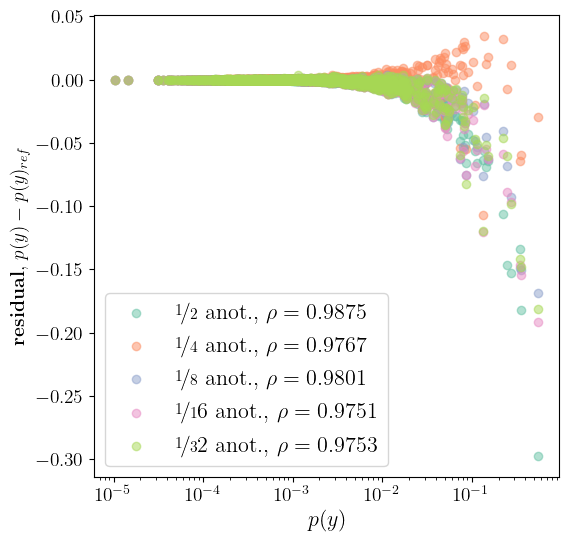

In [7]:
# plot the residuals of each downsampled run against the reference run
fig, ax = plt.subplots(figsize=(6, 6))

# usepackage units in plt latex preamble
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['text.latex.preamble'] = r'\usepackage{units}'

labels = {
    "downsampled_pt5": fr"\nicefrac{1}{2} anot., $\rho = {pearson_corrs[0]:.4f}$",
    "downsampled_pt25": fr"\nicefrac{1}{4} anot., $\rho = {pearson_corrs[1]:.4f}$",
    "downsampled_pt125": fr"\nicefrac{1}{8} anot., $\rho = {pearson_corrs[2]:.4f}$",
    "downsampled_pt0625": fr"\nicefrac{1}{16} anot., $\rho = {pearson_corrs[3]:.4f}$",
    "downsampled_pt05": fr"\nicefrac{1}{32} anot., $\rho = {pearson_corrs[4]:.4f}$"
}

blues = plt.cm.Set2
colors = {
    "downsampled_pt5": blues(0),
    "downsampled_pt25": blues(1),
    "downsampled_pt125": blues(2),
    "downsampled_pt0625": blues(3),
    "downsampled_pt05": blues(4)
}

for i, downsampled_run in enumerate(runs_to_compare.values()):
    ax.scatter(reference_run['p_y'], downsampled_run['p_y'] - reference_run['p_y'], label=f'{labels[list(runs_to_compare.keys())[i]]}', alpha=0.5, color=colors[list(runs_to_compare.keys())[i]])

ax.set_xlabel(r"$p(y)$", fontsize=16)
ax.set_ylabel(r"\textbf{residual}, $p(y) - p(y)_{ref}$", fontsize=14)

# log x scale 
ax.set_xscale('log')

ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)

ax.legend(fontsize=16)

In [8]:
# compute pearson and spearman correlations between reference run and downsampled runs. use scipy 

for i, downsampled_run in enumerate(runs_to_compare.values()):
    pearson_corr = stats.pearsonr(reference_run['p_y'], downsampled_run['p_y'])
    spearman_corr = stats.spearmanr(reference_run['p_y'], downsampled_run['p_y'])
    print(f"Pearson correlation between reference run and {list(runs_to_compare.keys())[i]} run: {pearson_corr}")
    print(f"Spearman correlation between reference run and {list(runs_to_compare.keys())[i]} run: {spearman_corr}")


Pearson correlation between reference run and downsampled_pt5 run: PearsonRResult(statistic=np.float64(0.9874572997073787), pvalue=np.float64(0.0))
Spearman correlation between reference run and downsampled_pt5 run: SignificanceResult(statistic=np.float64(0.9775037906757371), pvalue=np.float64(0.0))
Pearson correlation between reference run and downsampled_pt25 run: PearsonRResult(statistic=np.float64(0.9766791461075061), pvalue=np.float64(0.0))
Spearman correlation between reference run and downsampled_pt25 run: SignificanceResult(statistic=np.float64(0.9624046535429074), pvalue=np.float64(0.0))
Pearson correlation between reference run and downsampled_pt125 run: PearsonRResult(statistic=np.float64(0.9801411594938382), pvalue=np.float64(0.0))
Spearman correlation between reference run and downsampled_pt125 run: SignificanceResult(statistic=np.float64(0.9624535803643068), pvalue=np.float64(0.0))
Pearson correlation between reference run and downsampled_pt0625 run: PearsonRResult(statis

In [9]:
# Generate LaTeX table with Pearson and Spearman correlations
n_runs = len(runs_to_compare)
run_names = list(runs_to_compare.keys())

# Compute correlations
pearson_corrs = []
spearman_corrs = []

for run_name, downsampled_run in runs_to_compare.items():
    pearson_result = stats.pearsonr(reference_run['p_y'], downsampled_run['p_y'])
    spearman_result = stats.spearmanr(reference_run['p_y'], downsampled_run['p_y'])
    pearson_corrs.append(pearson_result.statistic)
    spearman_corrs.append(spearman_result.statistic)

# Generate LaTeX table
latex_table = "\\begin{tabular}{|c|" + "c|" * n_runs + "}\n"
latex_table += "\\hline\n"

# Header row
header = " & ".join([name.replace("_", "\\_") for name in run_names])
latex_table += header + " \\\\\n"
latex_table += "\\hline\n"

# Pearson row
pearson_row = " & ".join([f"{corr:.4f}" for corr in pearson_corrs])
latex_table += f"Pearson & {pearson_row} \\\\\n"

# Spearman row
spearman_row = " & ".join([f"{corr:.4f}" for corr in spearman_corrs])
latex_table += f"Spearman & {spearman_row} \\\\\n"

latex_table += "\\hline\n"
latex_table += "\\end{tabular}"

print(latex_table)


\begin{tabular}{|c|c|c|c|c|c|}
\hline
downsampled\_pt5 & downsampled\_pt25 & downsampled\_pt125 & downsampled\_pt0625 & downsampled\_pt05 \\
\hline
Pearson & 0.9875 & 0.9767 & 0.9801 & 0.9751 & 0.9753 \\
Spearman & 0.9775 & 0.9624 & 0.9625 & 0.9556 & 0.9466 \\
\hline
\end{tabular}
